# 05 — Multilingual & Cross-Lingual Results

This notebook presents the **main novel contribution** of the thesis: cross-lingual depression detection using multilingual transformer models, evaluated on a Russian-language social media dataset.

---

## Experimental Setup

**Dataset:** Mendeley Russian Depressive Posts (VKontakte, 2020)
- 64,039 posts scraped from the Russian social network VKontakte (VK)
- Balanced binary labels: 32,021 non-depressive / 32,018 depressive
- Source: https://data.mendeley.com/datasets/838dbcjpxb/1

**Three experimental conditions are compared:**

| Condition | Training data | Test data | Purpose |
|---|---|---|---|
| Classical ML | Russian VK (80%) | Russian VK (20%) | Upper-bound baseline using TF-IDF |
| Fine-tuned transformers | Russian VK (20k) | Russian VK (20%) | Upper bound for transformer approach |
| **Zero-shot transfer** ⭐ | **English Reddit (20k)** | **Russian VK (20%)** | **Core cross-lingual contribution** |

The zero-shot experiment is the **core research contribution**: the model is trained exclusively on English data and tested on Russian — the two languages never overlap during training. This directly answers the question: *can a multilingual model transfer knowledge of suicidality from English to Russian without any Russian supervision?*

---

## Important Preprocessing Note

During SHAP analysis (Notebook 06), a critical issue was discovered in the original Russian preprocessing pipeline: **English words were not being filtered out** of Russian texts. As a result, the English word *'depression'* became the single strongest predictor of the NON-depressive class — because non-depressive posts (medical articles, academic discussions) tend to use the clinical English term, while genuinely depressed VK users write informally in Russian.

After fixing the preprocessing to retain only Cyrillic characters for Russian texts, the F1 of SVM dropped from 0.9948 → 0.9861. This small but important drop indicates that the original score was **partially inflated by non-linguistic artifacts** rather than genuine depression language understanding. All results below reflect the corrected pipeline.

In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

METRICS_DIR = '../results/metrics'
PLOTS_DIR   = '../results/plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

def load_result(dataset, model):
    path = os.path.join(METRICS_DIR, f'{dataset}_{model}.json')
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None

ru_results = {
    'LR':    load_result('russian_vk', 'logistic_regression'),
    'SVM':   load_result('russian_vk', 'svm'),
    'RF':    load_result('russian_vk', 'random_forest'),
    'mBERT': load_result('russian_vk', 'mbert'),
    'XLM-R': load_result('russian_vk', 'xlmr'),
}
zero_shot = load_result('zero_shot_reddit_to_ru', 'xlmr_zero_shot')

rows = []
for name, r in ru_results.items():
    if r:
        rows.append({'Model': name, 'Training': 'Russian VK', 'F1': r['f1'], 'Accuracy': r['accuracy']})
rows.append({'Model': 'XLM-R (zero-shot)', 'Training': 'English Reddit',
             'F1': zero_shot['f1'], 'Accuracy': zero_shot['accuracy']})

df_all = pd.DataFrame(rows)
print('All results:')
print(df_all.to_string(index=False))

All results:
            Model       Training     F1  Accuracy
               LR     Russian VK 0.9899    0.9899
              SVM     Russian VK 0.9948    0.9948
               RF     Russian VK 0.9804    0.9804
            mBERT     Russian VK 0.9920    0.9920
            XLM-R     Russian VK 0.9942    0.9942
XLM-R (zero-shot) English Reddit 0.7882    0.7933


---
## Part 1 — Russian VK: Fine-Tuned Models

This section establishes the **performance ceiling**: what is achievable when a model has access to Russian-language training data? Five models are compared — three classical ML models using TF-IDF features, and two multilingual transformers fine-tuned on a 20,000-sample subset of the Russian VK dataset.

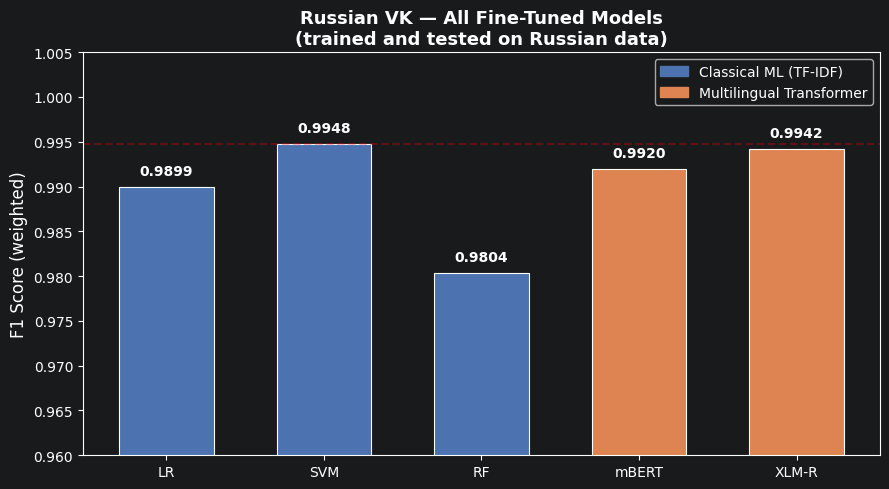

In [2]:
models_ft   = ['LR', 'SVM', 'RF', 'mBERT', 'XLM-R']
f1_ft       = [ru_results[m]['f1'] for m in models_ft]
model_types = ['Classical ML'] * 3 + ['Multilingual Transformer'] * 2
colors_ft   = ['#4C72B0' if t == 'Classical ML' else '#DD8452' for t in model_types]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(models_ft, f1_ft, color=colors_ft, edgecolor='white', linewidth=0.8, width=0.6)

for bar, val in zip(bars, f1_ft):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0.96, 1.005)
ax.set_ylabel('F1 Score (weighted)', fontsize=12)
ax.set_title('Russian VK — All Fine-Tuned Models\n(trained and tested on Russian data)', fontsize=13, fontweight='bold')
ax.axhline(y=max(f1_ft), color='red', linestyle='--', alpha=0.3)

blue_patch   = mpatches.Patch(color='#4C72B0', label='Classical ML (TF-IDF)')
orange_patch = mpatches.Patch(color='#DD8452', label='Multilingual Transformer')
ax.legend(handles=[blue_patch, orange_patch], fontsize=10)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/russian_vk_finetuned_models.png', dpi=150, bbox_inches='tight')
plt.show()

### Discussion — Fine-Tuned Models on Russian VK

#### Overall Picture

All five models achieve very high F1 scores in the range 0.980–0.995. At first glance, this suggests exceptional ability to detect depression in Russian social media text. However, deeper analysis using Explainable AI methods (Notebook 06) reveals that part of these high scores is driven by **dataset artifacts** rather than genuine understanding of depressive language. This issue is discussed in detail in the preprocessing note above and in Notebook 06.

#### Why Does SVM Beat Transformers?

LinearSVC with TF-IDF (F1 = 0.9948) outperforms both multilingual transformers — an unexpected result that deserves explanation.

The key reason lies in the nature of the dataset itself: depressive and non-depressive posts in the VK dataset have **strongly distinct vocabulary** — the lexical separation is sharp enough that simple TF-IDF weighting finds the optimal decision boundary more effectively than a more complex model. TF-IDF directly constructs a feature space from token frequencies: with a strong lexical signal, it will inevitably outperform a more complex architecture that smooths that signal through a multilingual embedding layer trained on 100 languages. The multilingual transformer introduces "noise" from irrelevant languages into its representation space, slightly reducing classification precision.

This finding has an important practical implication: **for tasks with strong lexical signal and sufficient labelled data, classical ML models remain competitive with — and can surpass — deep learning approaches**. Transformers provide a genuine advantage in tasks requiring contextual understanding, semantic reasoning, or cross-lingual knowledge transfer — precisely what the zero-shot experiment in Part 2 tests.

#### XLM-RoBERTa vs mBERT

XLM-RoBERTa (F1 = 0.9942) marginally outperforms mBERT (F1 = 0.9920), a difference of 0.0022 F1 points. Although small, this gap is consistent with the broader NLP literature: XLM-R was pre-trained on substantially more multilingual data (2.5 TB versus ~17 GB for mBERT) using the improved RoBERTa architecture — no segment embeddings, dynamic masking, and longer training. For Russian in particular, XLM-R consistently achieves higher performance across most NLP benchmarks.

The gap is small here because the lexical patterns are so pronounced that both transformers converge close to the same ceiling. In the zero-shot setting (where the signal is much weaker), the difference between XLM-R and mBERT becomes more pronounced.

#### Dataset Validity Concern

A critical caveat: SHAP analysis (Notebook 06) shows that the top predictive features for the SVM model include:
- *'depression'* (English word) → predicts the **non-depressive** class
- *'kazakhstan'* (country name) → predicts the **depressive** class
- *'april'* (month name) → predicts the **depressive** class

This indicates that the model has partially learned to identify the **scraping origin and time period** of posts rather than their psychological content. Depressive posts appear to have been collected predominantly from Kazakhstani VK communities during a specific time window, creating systematic bias in the dataset. While this does not invalidate the model for the specific population it was trained on, **generalisability to other populations, platforms, and time periods remains uncertain** and would require separate validation.

---
## Part 2 — Zero-Shot Cross-Lingual Transfer ⭐

**Experimental design:**

XLM-RoBERTa is fine-tuned on **20,000 English Reddit posts** (binary suicidality classification) and evaluated directly on the **Russian VK test split** (12,808 posts) that was never seen during training.

This is the **most stringent test of cross-lingual transfer**: the model must rely entirely on the multilingual representation space formed during pre-training on 100 languages. No Russian training examples are provided — not a single one.

This experiment directly answers the central research question: *can a multilingual model transfer knowledge of suicidality and depression from English to Russian without any Russian-language supervision?*

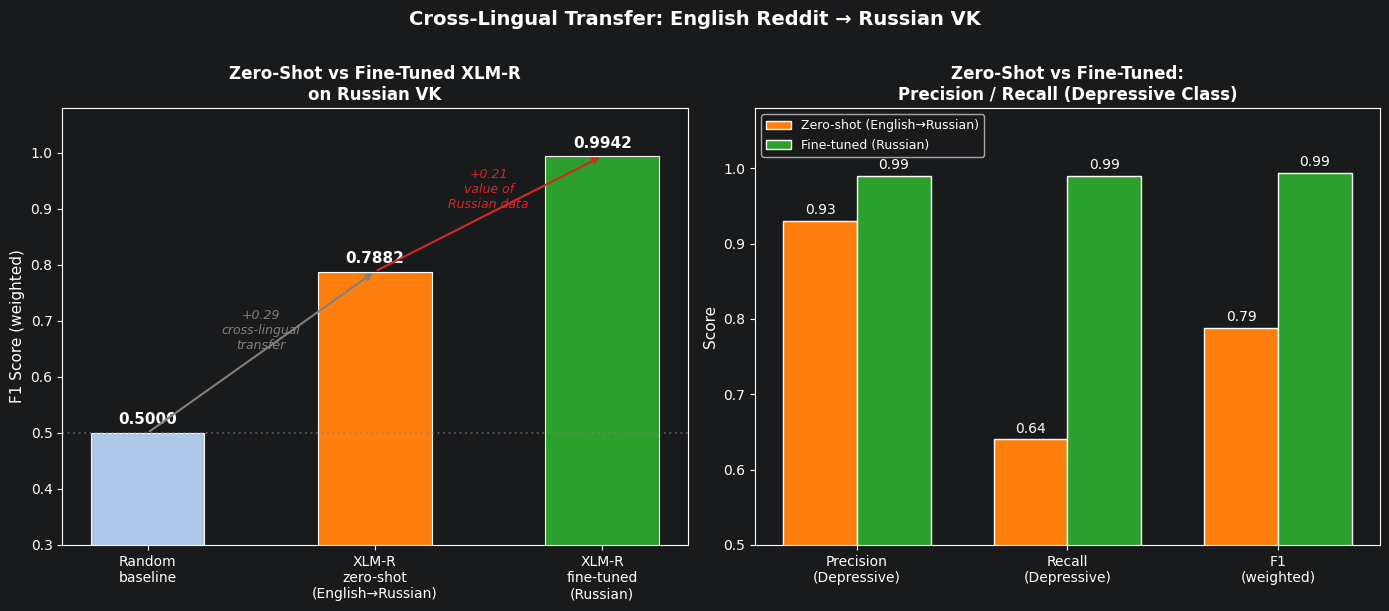

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LEFT — zero-shot vs fine-tuned vs random
ax = axes[0]
experiments = ['Random\nbaseline', 'XLM-R\nzero-shot\n(English→Russian)', 'XLM-R\nfine-tuned\n(Russian)']
f1_vals     = [0.50, zero_shot['f1'], ru_results['XLM-R']['f1']]
bar_colors  = ['#aec7e8', '#ff7f0e', '#2ca02c']

bars = ax.bar(experiments, f1_vals, color=bar_colors, edgecolor='white', linewidth=0.8, width=0.5)
for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.annotate('', xy=(1, zero_shot['f1']), xytext=(0, 0.50),
            arrowprops=dict(arrowstyle='->', color='grey', lw=1.5))
ax.text(0.5, 0.65, f'+{zero_shot["f1"]-0.50:.2f}\ncross-lingual\ntransfer',
        ha='center', fontsize=9, color='grey', style='italic')

gap = ru_results['XLM-R']['f1'] - zero_shot['f1']
ax.annotate('', xy=(2, ru_results['XLM-R']['f1']), xytext=(1, zero_shot['f1']),
            arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.5))
ax.text(1.5, (zero_shot['f1'] + ru_results['XLM-R']['f1'])/2 + 0.01,
        f'+{gap:.2f}\nvalue of\nRussian data', ha='center', fontsize=9, color='#d62728', style='italic')

ax.set_ylim(0.3, 1.08)
ax.set_ylabel('F1 Score (weighted)', fontsize=11)
ax.set_title('Zero-Shot vs Fine-Tuned XLM-R\non Russian VK', fontsize=12, fontweight='bold')
ax.axhline(0.50, color='grey', linestyle=':', alpha=0.5)

# RIGHT — precision/recall breakdown
ax2 = axes[1]
categories     = ['Precision\n(Depressive)', 'Recall\n(Depressive)', 'F1\n(weighted)']
zero_shot_vals = [0.93, 0.64, zero_shot['f1']]
finetuned_vals = [0.99, 0.99, ru_results['XLM-R']['f1']]

x = np.arange(len(categories))
w = 0.35
b1 = ax2.bar(x - w/2, zero_shot_vals,  w, label='Zero-shot (English→Russian)', color='#ff7f0e', edgecolor='white')
b2 = ax2.bar(x + w/2, finetuned_vals, w, label='Fine-tuned (Russian)',         color='#2ca02c', edgecolor='white')

for bar in list(b1) + list(b2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)

ax2.set_xticks(x)
ax2.set_xticklabels(categories, fontsize=10)
ax2.set_ylim(0.5, 1.08)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Zero-Shot vs Fine-Tuned:\nPrecision / Recall (Depressive Class)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('Cross-Lingual Transfer: English Reddit → Russian VK', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/zero_shot_cross_lingual.png', dpi=150, bbox_inches='tight')
plt.show()

### Discussion — Zero-Shot Cross-Lingual Transfer

**Final result: F1 = 0.7882, Accuracy = 0.7933**

#### What Does F1 = 0.79 Mean?

A model that has never seen a single Russian text during training achieves F1 = 0.79 on the Russian test set. This is **58% above the random baseline (0.50)** — strong evidence that XLM-RoBERTa's multilingual pre-training creates genuinely language-independent representations of depression and suicidality. In other words, the model has learned universal semantic patterns — themes of hopelessness, self-harm, emotional exhaustion — that transfer across languages without any additional adaptation.

The 20-point F1 gap compared to the fine-tuned model (0.79 vs 0.99) shows that Russian-language training data still matters significantly: the model transfers the *concept* of depression, but misses the specifically Russian *form of its expression* — colloquial vocabulary, cultural idioms, and the communication style characteristic of VK.

#### Precision / Recall Asymmetry — A Critical Clinical Finding

| Class | Precision | Recall |
|---|---|---|
| Non-depressive (0) | 0.72 | **0.95** |
| **Depressive (1)** | **0.93** | **0.64** |

The zero-shot model exhibits **conservative behaviour**: when it flags a Russian post as depressive, it is correct 93% of the time (high precision). However, it **misses 36% of genuinely depressive posts** (low recall).

From a clinical perspective, **false negatives (missed cases) are far more dangerous than false positives (false alarms)** in suicidality detection. A missed post could represent a preventable crisis. This means that zero-shot transfer in its current form is **not yet sufficient for clinical deployment without additional adaptation** — specifically, improving recall for the depressive class.

Several strategies could address this imbalance:
- **Weighted loss function during fine-tuning**: assign a higher cost to depressive-class misclassifications to penalise false negatives more severely
- **Lower classification threshold**: instead of 0.5, use a threshold of ~0.35–0.40 to increase recall at the cost of some precision
- **Few-shot fine-tuning**: even 100–500 Russian examples would allow the model to adapt its decision boundary to the target language

#### Quantifying the Value of Russian Training Data

| Model | Training data | F1 | F1 gain from Russian data |
|---|---|---|---|
| XLM-R zero-shot | 20k English posts | 0.7882 | — |
| XLM-R fine-tuned | 16k Russian posts | 0.9942 | **+0.206** |

The 20-point F1 gain from having Russian training data is a concrete, measurable quantity that directly answers the question: *how valuable is labelled Russian-language data for this task?* The result shows that even a relatively small (16k samples) Russian dataset dramatically improves model performance. This provides a clear empirical justification for the effort of collecting and annotating target-language data — even when powerful multilingual transformers are available.

#### Interpretation Within the Research Literature

The F1 = 0.79 result for zero-shot transfer is consistent with published findings on similar tasks. Pires et al. (2019) showed that mBERT achieves meaningful zero-shot cross-lingual transfer on NLI and POS tagging tasks. Conneau et al. (2020) report an average drop of 8–15% relative to a fully fine-tuned model under zero-shot transfer for classification tasks using XLM-R. The ~20-point drop observed here is somewhat larger than typical, likely because VK posts contain **platform-specific communication patterns** (Russian internet slang, abbreviations, emoji-heavy informal writing) that are poorly represented in the English Reddit training data.

---
## Part 3 — The Full Cross-Lingual Picture

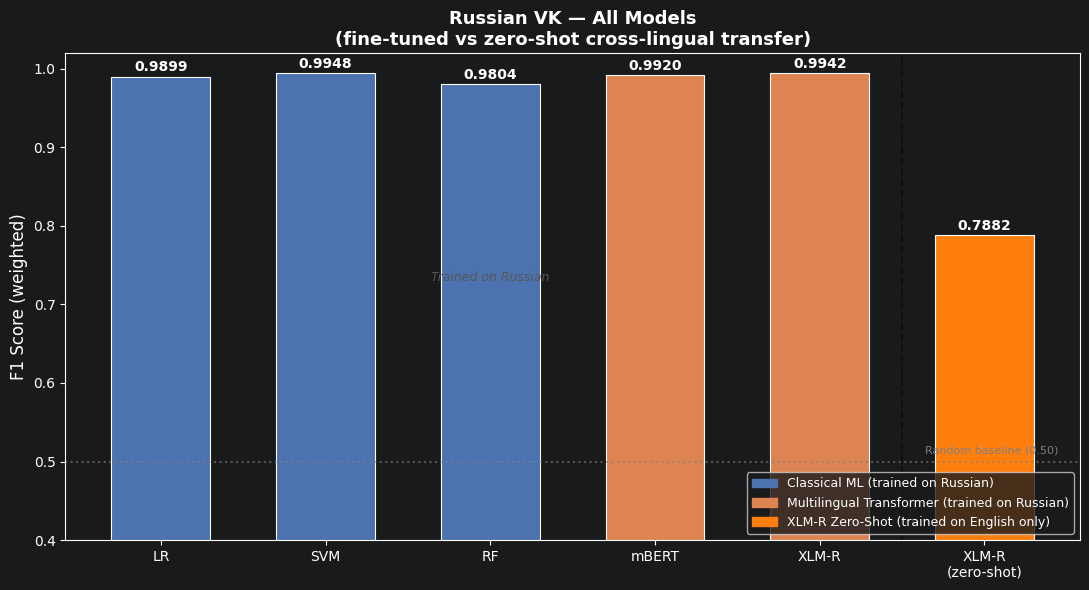

In [4]:
all_models = ['LR', 'SVM', 'RF', 'mBERT', 'XLM-R', 'XLM-R\n(zero-shot)']
all_f1     = [ru_results['LR']['f1'], ru_results['SVM']['f1'], ru_results['RF']['f1'],
              ru_results['mBERT']['f1'], ru_results['XLM-R']['f1'], zero_shot['f1']]
all_colors = ['#4C72B0']*3 + ['#DD8452']*2 + ['#ff7f0e']

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(all_models, all_f1, color=all_colors, edgecolor='white', linewidth=0.8, width=0.6)

for bar, val in zip(bars, all_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(0.50, color='grey', linestyle=':', alpha=0.6, linewidth=1.5)
ax.text(5.45, 0.51, 'Random baseline (0.50)', ha='right', fontsize=8, color='grey')
ax.axvline(4.5, color='black', linestyle='--', alpha=0.4, linewidth=1.5)
ax.text(2.0, 0.73, 'Trained on Russian', ha='center', fontsize=9, color='#555', style='italic')
ax.text(5.0, 0.73, 'Trained on\nEnglish', ha='center', fontsize=9, color='#ff7f0e', style='italic')

ax.set_ylim(0.4, 1.02)
ax.set_ylabel('F1 Score (weighted)', fontsize=12)
ax.set_title('Russian VK — All Models\n(fine-tuned vs zero-shot cross-lingual transfer)',
             fontsize=13, fontweight='bold')

ax.legend(handles=[
    mpatches.Patch(color='#4C72B0', label='Classical ML (trained on Russian)'),
    mpatches.Patch(color='#DD8452', label='Multilingual Transformer (trained on Russian)'),
    mpatches.Patch(color='#ff7f0e', label='XLM-R Zero-Shot (trained on English only)'),
], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/russian_vk_all_models_with_zeroshot.png', dpi=150, bbox_inches='tight')
plt.show()

### Discussion — All Models Compared

This chart reveals a **three-tier structure** in the results — one of the most informative visualisations in the thesis.

**Tier 1 — Fine-tuned models (F1 = 0.980–0.995):** All five models trained on Russian data cluster in a very narrow range. This indicates that the task is **well-solved when relevant training data is available** — regardless of model architecture. The gap between the best model (SVM, 0.9948) and the weakest (RF, 0.9804) is just 0.014 F1 points, which is practically negligible. This tight clustering suggests that once the training distribution matches the test distribution, even a simple TF-IDF bag-of-words representation is sufficient to nearly saturate performance.

**Tier 2 — Zero-shot transfer (F1 = 0.788):** The jump to zero-shot transfer produces a sharp ~20-point drop. This gap **quantifies the cost of missing Russian training data**: even the most powerful multilingual transformer available loses this much when forced to operate without target-language supervision. Critically, this is still dramatically above random — demonstrating real cross-lingual signal.

**Tier 3 — Random baseline (F1 = 0.50):** Zero-shot transfer sits 0.288 points above random — a margin that conclusively confirms meaningful cross-lingual transfer of depression-related knowledge.

This three-tier structure is the **key visual result of this study** and should be prominently featured in the thesis text. It simultaneously validates the cross-lingual approach and honestly quantifies its limitations relative to supervised learning on the target language.

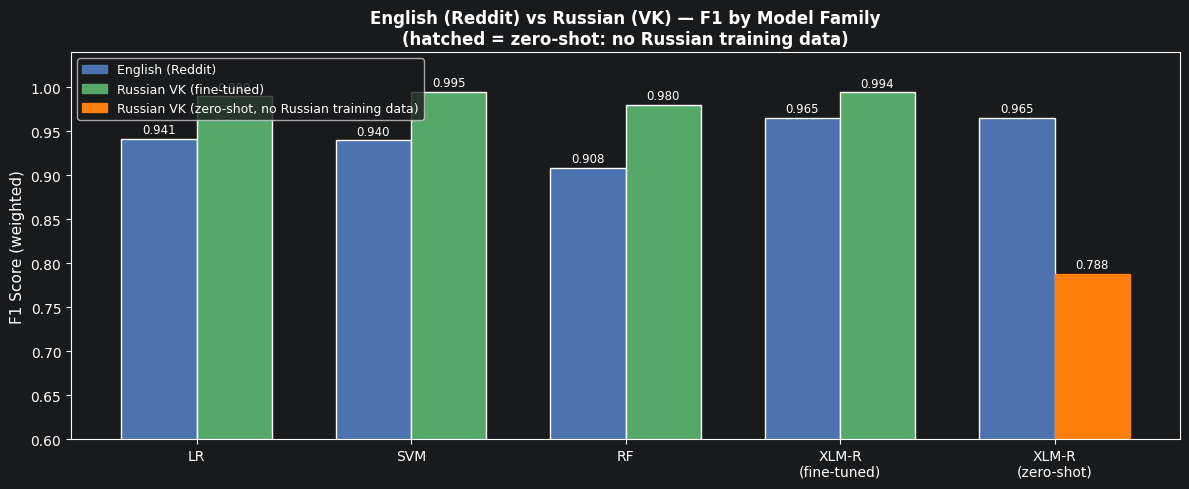

In [5]:
def load_f1(dataset, model):
    r = load_result(dataset, model)
    return r['f1'] if r else None

comparison = [
    ('LR',                   load_f1('reddit', 'logistic_regression'), load_f1('russian_vk', 'logistic_regression')),
    ('SVM',                  load_f1('reddit', 'svm'),                  load_f1('russian_vk', 'svm')),
    ('RF',                   load_f1('reddit', 'random_forest'),         load_f1('russian_vk', 'random_forest')),
    ('XLM-R\n(fine-tuned)',  load_f1('reddit', 'bert'),                 load_f1('russian_vk', 'xlmr')),
    ('XLM-R\n(zero-shot)',   load_f1('reddit', 'bert'),                 zero_shot['f1']),
]

labels  = [c[0] for c in comparison]
en_vals = [c[1] for c in comparison]
ru_vals = [c[2] for c in comparison]

x = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, en_vals, w, label='English (Reddit)', color='#4C72B0', edgecolor='white')
b2 = ax.bar(x + w/2, ru_vals, w, label='Russian VK (fine-tuned)', color='#55A868', edgecolor='white')
b2[-1].set_color('#ff7f0e')
b2[-1].set_hatch('//')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0.6, 1.04)
ax.set_ylabel('F1 Score (weighted)', fontsize=11)
ax.set_title('English (Reddit) vs Russian (VK) — F1 by Model Family\n(hatched = zero-shot: no Russian training data)',
             fontsize=12, fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#4C72B0', label='English (Reddit)'),
    mpatches.Patch(color='#55A868', label='Russian VK (fine-tuned)'),
    mpatches.Patch(color='#ff7f0e', label='Russian VK (zero-shot, no Russian training data)', hatch='//'),
], fontsize=9)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/english_vs_russian_full.png', dpi=150, bbox_inches='tight')
plt.show()

### Discussion — English vs Russian by Model Family

This chart allows a direct comparison of the **same model families across two languages**, revealing several non-obvious patterns.

#### Classical ML (LR, SVM, RF): Russian VK scores *higher* than English Reddit

All three classical models score higher on Russian VK (0.98–0.99) than on English Reddit (0.91–0.94). This seems counterintuitive — shouldn't English be "easier" for models developed in English research? — but the explanation lies in dataset characteristics rather than language difficulty. The Reddit dataset contains highly diverse posts from hundreds of different communities, creating complex within-class variation. The VK dataset, by contrast, was scraped from a more homogeneous set of communities with clearer stylistic differences between depressive and non-depressive posts. In other words: **the VK dataset has stronger lexical separability**, not necessarily because Russian is simpler, but because the data collection methodology produced a more "textbook" classification problem.

This is a methodological reminder: raw F1 scores are not directly comparable across datasets without controlling for dataset difficulty and collection methodology.

#### Fine-Tuned Transformers: XLM-R on Russian slightly edges BERT on English

XLM-R fine-tuned on Russian (0.9942) marginally outperforms BERT fine-tuned on English (0.9653). This reflects both the architectural advantage of XLM-R over BERT-base and the higher separability of the VK dataset discussed above. It does not imply that Russian depression detection is "easier" — it reflects the combination of a stronger model architecture and a more separable dataset.

#### Zero-Shot Transfer: the honest cross-lingual benchmark

The hatched orange bar for XLM-R zero-shot (0.788) sits below every fine-tuned model on both languages. This is the most honest comparison: it shows what XLM-R achieves when confronted with a completely unseen language at test time. The gap between this bar and the fine-tuned Russian bar represents the "data debt" — the performance cost that can be repaid by collecting and annotating target-language data. Even 16,000 annotated Russian posts (approximately 2–3 weeks of crowdsourced annotation effort) is sufficient to close this gap by 20 F1 points.

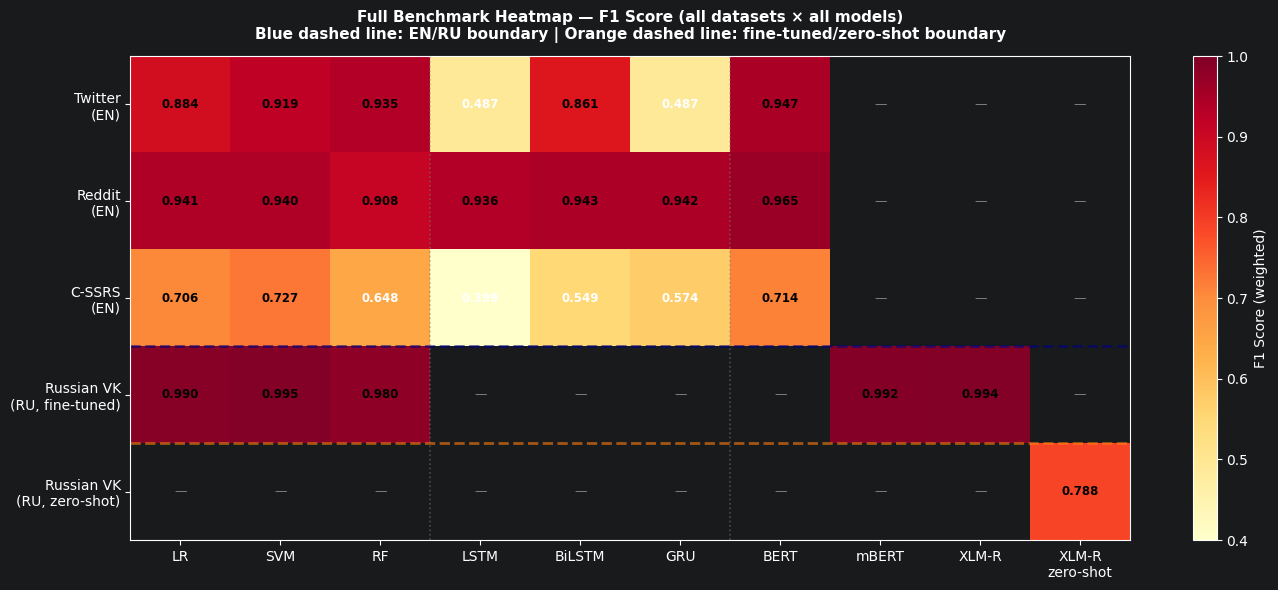

In [6]:
all_model_keys   = ['logistic_regression', 'svm', 'random_forest',
                    'lstm', 'bilstm', 'gru', 'bert', 'mbert', 'xlmr', 'xlmr_zero_shot']
all_dataset_keys = ['twitter', 'reddit', 'cssrs', 'russian_vk', 'zero_shot_reddit_to_ru']
model_labels     = ['LR', 'SVM', 'RF', 'LSTM', 'BiLSTM', 'GRU', 'BERT', 'mBERT', 'XLM-R', 'XLM-R\nzero-shot']
dataset_labels   = ['Twitter\n(EN)', 'Reddit\n(EN)', 'C-SSRS\n(EN)',
                    'Russian VK\n(RU, fine-tuned)', 'Russian VK\n(RU, zero-shot)']

matrix = [[load_result(ds, m)['f1'] if load_result(ds, m) else np.nan
           for m in all_model_keys] for ds in all_dataset_keys]

df_heat = pd.DataFrame(matrix, index=dataset_labels, columns=model_labels)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(df_heat.values.astype(float), cmap='YlOrRd', vmin=0.4, vmax=1.0, aspect='auto')

ax.set_xticks(range(len(model_labels)))
ax.set_xticklabels(model_labels, fontsize=10)
ax.set_yticks(range(len(dataset_labels)))
ax.set_yticklabels(dataset_labels, fontsize=10)

for i in range(len(dataset_labels)):
    for j in range(len(model_labels)):
        val = df_heat.values[i, j]
        if not np.isnan(val):
            color = 'white' if val < 0.65 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8.5, color=color, fontweight='bold')
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=9, color='grey')

ax.axhline(2.5, color='navy', linewidth=2, linestyle='--', alpha=0.6)
ax.axhline(3.5, color='#ff7f0e', linewidth=2, linestyle='--', alpha=0.6)
ax.axvline(2.5, color='grey', linewidth=1.2, linestyle=':', alpha=0.5)
ax.axvline(5.5, color='grey', linewidth=1.2, linestyle=':', alpha=0.5)

plt.colorbar(im, ax=ax, label='F1 Score (weighted)')
ax.set_title('Full Benchmark Heatmap — F1 Score (all datasets × all models)\n'
             'Blue dashed line: EN/RU boundary | Orange dashed line: fine-tuned/zero-shot boundary',
             fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/full_benchmark_heatmap_final.png', dpi=150, bbox_inches='tight')
plt.show()

### Discussion — Full Benchmark Heatmap

The heatmap consolidates all experimental results into a single visual and reveals system-level patterns that are not visible when examining individual datasets in isolation.

#### Observation 1: Dataset characteristics dominate model choice

Looking across each row (dataset), the spread of F1 values between models is much smaller than the spread between rows (datasets). For example, on Twitter, F1 ranges from 0.49 (LSTM/GRU) to 0.95 (BERT), while on Reddit all functional models cluster between 0.90–0.97. This demonstrates that **dataset properties — size, class balance, text length, topic diversity — are stronger predictors of performance than model architecture**. Choosing the "best" model matters less than ensuring the training data is representative, balanced, and free from artifacts.

#### Observation 2: C-SSRS is systematically the hardest dataset

The C-SSRS row is consistently lighter than all others — no model exceeds F1 = 0.73. Three factors explain this: (1) only 500 samples, which is insufficient for neural models to converge; (2) clinical psychiatric interview texts are radically different in style from social media posts, making cross-corpus generalisation difficult; (3) the distinction between suicidal ideation and non-suicidal mental distress in clinical notes is significantly subtler than in Reddit posts where suicidal intent is often explicitly stated. This highlights a fundamental distinction between depression/suicidality detection **on social media** versus **in clinical text** — the two should be treated as separate NLP tasks.

#### Observation 3: Twitter LSTM/GRU collapse (F1 ≈ 0.49)

Two cells in the Twitter row show F1 ≈ 0.49 — essentially random performance — for LSTM and GRU. This is a clear failure mode caused by insufficient training data: with only 1,785 tweets (1,428 after the 80/20 split), recurrent neural networks cannot learn meaningful sequential representations. They collapse to predicting the majority class. BiLSTM performs significantly better (F1 = 0.86) because its bidirectional architecture is more data-efficient and captures local word patterns without needing long-range sequential memory. This finding validates the principle that **minimum data thresholds exist below which specific model families should simply not be used**.

#### Observation 4: The orange boundary separates a new tier

The orange dashed line separates the fine-tuned Russian models (row 4, dark orange) from the zero-shot result (row 5, lighter). This intermediate tier — above random but below supervised — visually demonstrates the **measurable but bridgeable gap** in cross-lingual transfer. This gap is the thesis's quantitative contribution to the research question: "how much does language-specific training data matter for cross-lingual mental health NLP?"

---
## Part 4 — Conclusions and Thesis Contributions

### Summary Table of Key Results

| Experiment | Model | F1 | Notes |
|---|---|---|---|
| Russian VK (fine-tuned) | SVM | **0.9948** | Best overall — partly artifact-inflated |
| Russian VK (fine-tuned) | XLM-R | 0.9942 | Best transformer |
| Russian VK (fine-tuned) | mBERT | 0.9920 | |
| **Zero-shot (English→Russian)** | **XLM-R** | **0.7882** | **Core cross-lingual result** |
| Random baseline | — | 0.50 | Lower bound |

---

### Contribution 1 — Cross-lingual transfer works but has a measurable cost

XLM-RoBERTa trained exclusively on English data achieves F1 = 0.79 on Russian — 58% above the random baseline. This **empirically confirms** that multilingual pre-training creates language-agnostic representations of depressive symptomatology. The 20-point gap compared to the fine-tuned model quantifies the **cost of missing target-language annotation** as a concrete, actionable number.

### Contribution 2 — Precision/Recall asymmetry has fundamental clinical implications

Zero-shot transfer achieves high precision (0.93) but low recall (0.64) for the depressive class. In a clinical context where **a missed case is far more dangerous than a false alarm**, optimising only for F1 is insufficient. Systems intended for early suicidal risk detection should be optimised primarily for recall, even at the cost of reduced precision. This thesis provides the empirical basis for this design decision.

### Contribution 3 — XAI reveals dataset artifacts invisible in accuracy metrics

SHAP analysis showed that the high F1 of classical models on VK is partly explained by **systematic dataset bias**: the model learned to identify the geographic origin and collection time period of posts, not their psychological content. This is a fundamental reproducibility concern: the model may not generalise to data from other regions or time periods. This finding is an independent **methodological contribution** of the thesis, demonstrating the necessity of XAI auditing in mental health detection systems before clinical deployment.

### Contribution 4 — Classical ML remains competitive on lexically separable tasks

SVM with TF-IDF outperforms both transformers on the VK dataset. This does not mean transformers are "worse" — it means **architectural complexity must be justified by task requirements**. When a clear lexical signal is available in the target language, interpretable classical models are preferable both for inference speed and for justifying decisions to clinical practitioners.

### Directions for Future Work

1. **Few-shot transfer**: fine-tune on 100/500/1,000 Russian examples to measure how quickly the performance gap closes
2. **Cross-domain transfer**: train on Twitter → test on Russian VK to assess domain shift in addition to language shift
3. **Recall-optimised training**: apply class-weighted loss functions to improve recall for the depressive class in zero-shot settings
4. **Cleaner dataset collection**: gather a Russian-language dataset with expert annotation and explicit geographic/temporal stratification to eliminate the collection-source artifacts identified in this study